In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
# 1. Creazione di Dait Sintetici
np.random.seed(42)
X = np.random.rand(100, 10)  # 10 predittori (alcuni irrilevanti)
# Y è principalmente basato su X[:, 0] e X[:, 1]
y = 5 * X[:,0] - 2 * X[:,1] + 0.1 * X[:, 9] + np.random.randn(100)*0.5
# Dataset di esempio.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)
# 1. Decision Tree
dt = DecisionTreeRegressor(max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("MSE Decision Tree:", mean_squared_error(y_test, y_pred_dt))
# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=5)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("MSE Random Forest:", mean_squared_error(y_test, y_pred_rf))
# 3. Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1 ,max_depth=3)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("MSE Gradient Boosting:", mean_squared_error(y_test, y_pred_gb))
# 4. XGBoost
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', max_depth=3, n_estimators=100, learning_rate=0.1)
xg_reg.fit(X_train, y_train)
y_pred_xbg = xg_reg.predict(X_test)
print("MSE XGBoost:", mean_squared_error(y_test, y_pred_xbg))

La libreria scikit learn fornisce per implementare l'algoritmo GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Definiamo la griglia di parametri XGBoost
param_grid = {
    'n_estimators': [50,100, 200],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth': [3,5,7],
    'subsample' : [0.8,1.0]
}

# 2. Inizializziamo il modello e la ricerca
xgb_model = xgb.XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,                   # 5-fold Cross-Validation
    scoring='neg_mean_squared_error',
    verbose=1
)

# 2. Inizializziamo il modello e la ricerca
grid_search.fit(X_train, y_train)

# 4. Risultati
print(f"Migliori Parametri: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# Confronto finale sul test set
best_preds = best_model.predict(X_test)
print(f"MSE Modello Ottimizzato: {mean_squared_error(y_test, best_preds):.5f}")



Valutazione delle feature tramite Partial Dependence Plots

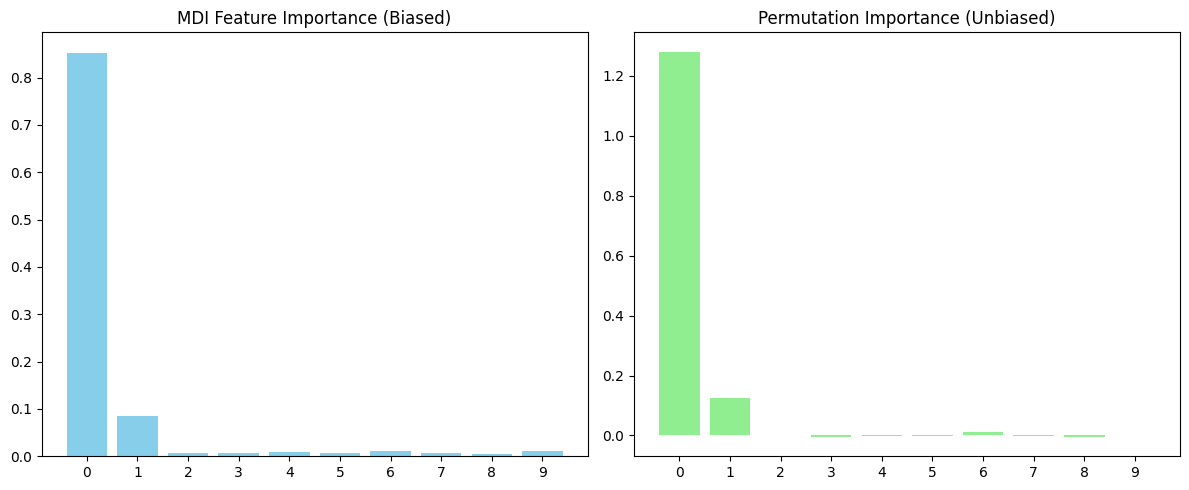

Generazione del Partial Dependence Plots...


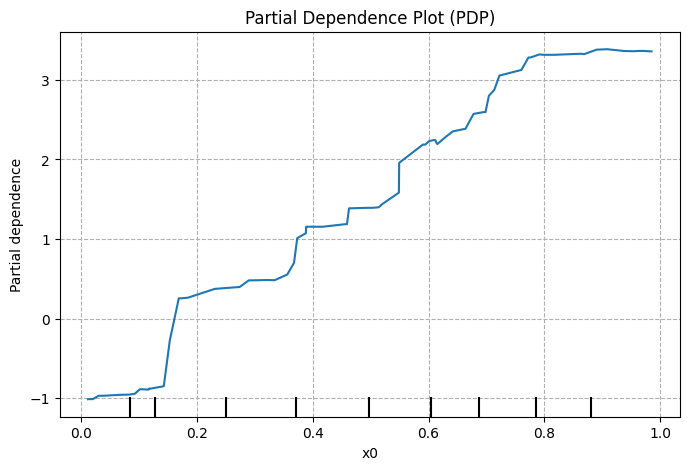

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Training del modello
rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

# 1. Feature Importance MDI (estratta direttamente dal modello)
mdi_importances = rf_model.feature_importances_

# 2. Permutation Importance (calcolata e salvata nell'oggetto Bunch)
perm_result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)

# 3 visualizzazione Feature Importance vs Permutation
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Plot Feature Importance MDI su ax[0]
ax[0].bar(range(X_test.shape[1]), mdi_importances, color='skyblue')
ax[0].set_title("MDI Feature Importance (Biased)")
ax[0].set_xticks(range(X_test.shape[1]))

# Plot Permutation Importance su ax[1] (estraendo .importances_mean dal Bunch)
ax[1].bar(range(X_test.shape[1]), perm_result.importances_mean, color='lightgreen')
ax[1].set_title("Permutation Importance (Unbiased)")
ax[1].set_xticks(range(X_test.shape[1]))

plt.tight_layout()
plt.show()

# 4. Partial Dependence Plots (PDP)
print("Generazione del Partial Dependence Plots...")
fig, ax = plt.subplots(figsize=(8,5))
PartialDependenceDisplay.from_estimator(rf_model, X_train, features=[0], ax=ax)
plt.title("Partial Dependence Plot (PDP)")
plt.grid(True, linestyle='--')
plt.show()
